
# Mobile Prices 2025 — EDA & Value-for-Money Analysis

**Objective:** Data analyst through an end-to-end exploratory data analysis (EDA) on a global mobile prices dataset.  
We will:  
1. Load and inspect the data  
2. Summarize price distribution by operating system (OS)  
3. Explore feature-price relationships  
4. Build a Value Score + Price-to-Value Ratio  
5. Visualize insights  


In [4]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 160)



## Why these imports?
- **pandas** → data manipulation  
- **numpy** → numeric operations  
- **matplotlib** → visualizations  


In [5]:
df = pd.read_csv(r"C:\Users\singh\OneDrive\Desktop\Python\Project\Global_Mobile_Prices_2025_Extended.csv")

print("Loaded rows:", len(df))
df.head()

Loaded rows: 1000


,brand,model,price_usd,ram_gb,storage_gb,camera_mp,battery_mah,display_size_inch,charging_watt,5g_support,os,processor,rating,release_month,year
0,Oppo,A98 111,855,16,128,108,6000,6.6,33,Yes,Android,Helio G99,3.8,February,2025
1,Realme,11 Pro+ 843,618,6,128,64,4500,6.9,100,Yes,Android,Tensor G4,4.4,August,2025
2,Xiaomi,Redmi Note 14 Pro 461,258,16,64,64,4000,6.8,44,Yes,Android,A18 Pro,4.1,March,2025
3,Vivo,V29e 744,837,6,512,48,4500,6.0,65,Yes,Android,Exynos 2400,4.1,August,2025
4,Apple,iPhone 16 Pro Max 927,335,12,128,200,5000,6.9,100,Yes,iOS,Dimensity 9300,3.5,February,2025


## Initial Data Exploration

In [20]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   brand                 1000 non-null   object 
 1   model                 1000 non-null   object 
 2   price_usd             1000 non-null   int64  
 3   ram_gb                1000 non-null   int64  
 4   storage_gb            1000 non-null   int64  
 5   camera_mp             1000 non-null   int64  
 6   battery_mah           1000 non-null   int64  
 7   display_size_inch     1000 non-null   float64
 8   charging_watt         1000 non-null   int64  
 9   5g_support            1000 non-null   object 
 10  os                    1000 non-null   object 
 11  processor             1000 non-null   object 
 12  rating                1000 non-null   float64
 13  release_month         1000 non-null   object 
 14  year                  1000 non-null   int64  
 15  ram_gb_norm           

In [ ]:

missing_summary = df.isna().sum().sort_values(ascending=False)
missing_summary.head(20)

brand                   0
model                   0
price_usd               0
ram_gb                  0
storage_gb              0
camera_mp               0
battery_mah             0
display_size_inch       0
charging_watt           0
5g_support              0
os                      0
processor               0
rating                  0
release_month           0
year                    0
ram_gb_norm             0
camera_mp_norm          0
battery_mah_norm        0
Value_Score             0
Price_to_Value_Ratio    0
dtype: int64


**Why this step?**  
To identify:  
- Data types  
- Missing values  
- Potential need for cleaning  


In [7]:

numeric_cols_guess = ['price_usd', 'ram_gb', 'storage_gb', 'camera_mp', 'battery_mah', 'display_size_inch', 'charging_watt', 'rating']

for col in numeric_cols_guess:
    if col in df.columns:
        if not pd.api.types.is_numeric_dtype(df[col]):
            df[col] = pd.to_numeric(df[col], errors='coerce')

required = [c for c in ['price_usd','ram_gb','camera_mp','battery_mah'] if c in df.columns]
df = df.dropna(subset=required)
print("Cleaned rows:", len(df))


Cleaned rows: 1000



### Why convert & drop?
- Ensures numeric calculations work  
- Drops rows missing critical fields  


In [8]:

if 'os' in df.columns and 'price_usd' in df.columns:
    os_price_summary = df.groupby('os')['price_usd'].agg(['count','mean','median','std','min','max']).sort_values('mean', ascending=False)
    os_price_summary
else:
    print("OS or price column missing.")



### Why group by OS?
Shows differences in pricing strategies between platforms.


<Figure size 1000x600 with 0 Axes>

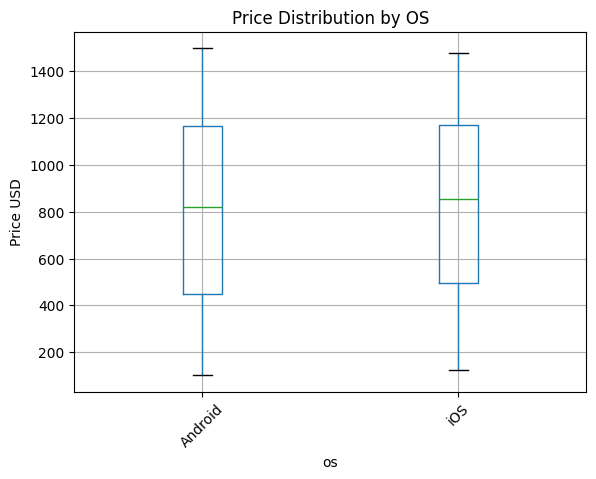

In [9]:

if 'os' in df.columns:
    plt.figure(figsize=(10,6))
    df.boxplot(column='price_usd', by='os', rot=45)
    plt.title('Price Distribution by OS')
    plt.suptitle('')
    plt.ylabel('Price USD')
    plt.show()



### Interpretation
- Median prices differ across OS  
- Spread shows pricing diversity within each OS  


In [10]:

num_cols = [c for c in numeric_cols_guess if c in df.columns]
corr_df = df[num_cols]
corr_matrix = corr_df.corr(method='spearman')
corr_matrix


,price_usd,ram_gb,storage_gb,camera_mp,battery_mah,display_size_inch,charging_watt,rating
price_usd,1.000000,-0.028837,0.010384,0.016516,-0.006361,-0.024238,0.013088,-0.003703
ram_gb,-0.028837,1.000000,0.005827,-0.003512,0.019910,-0.002249,0.004292,-0.053591
storage_gb,0.010384,0.005827,1.000000,0.053413,-0.036006,0.029686,0.042745,0.032795
camera_mp,0.016516,-0.003512,0.053413,1.000000,0.017188,-0.028510,0.006898,0.015270
battery_mah,-0.006361,0.019910,-0.036006,0.017188,1.000000,0.013161,0.000487,0.009429
display_size_inch,-0.024238,-0.002249,0.029686,-0.028510,0.013161,1.000000,0.055399,0.016103
charging_watt,0.013088,0.004292,0.042745,0.006898,0.000487,0.055399,1.000000,0.026971
rating,-0.003703,-0.053591,0.032795,0.015270,0.009429,0.016103,0.026971,1.000000


In [11]:

if 'price_usd' in corr_matrix.columns:
    price_corr = corr_matrix['price_usd'].drop('price_usd').sort_values(ascending=False)
    price_corr

if 'rating' in corr_matrix.columns:
    rating_corr = corr_matrix['rating'].drop('rating').sort_values(ascending=False)
    rating_corr


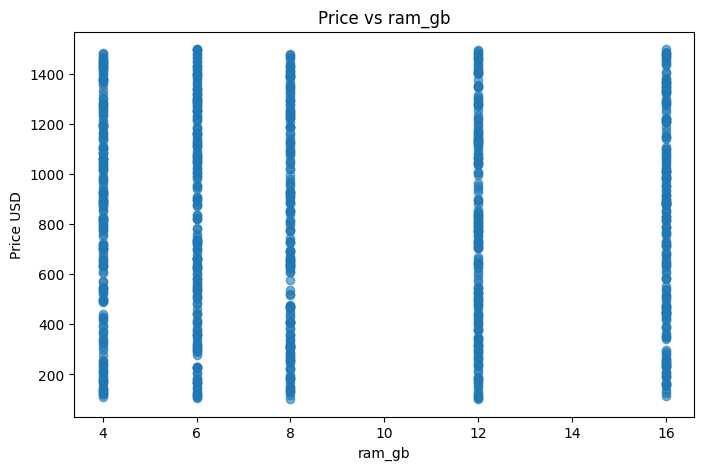

In [12]:

top_feature = price_corr.abs().idxmax()

plt.figure(figsize=(8,5))
plt.scatter(df[top_feature], df['price_usd'], alpha=0.6)
plt.xlabel(top_feature)
plt.ylabel('Price USD')
plt.title(f'Price vs {top_feature}')
plt.show()


In [13]:

specs = ['ram_gb','camera_mp','battery_mah']
specs = [s for s in specs if s in df.columns]

for s in specs:
    df[s + '_norm'] = (df[s] - df[s].min()) / (df[s].max() - df[s].min())

df['Value_Score'] = df[[s+'_norm' for s in specs]].sum(axis=1)

df['Price_to_Value_Ratio'] = df['price_usd'] / df['Value_Score']


In [ ]:
df.sort_values('Price_to_Value_Ratio').head(10)[['brand','model','price_usd','Value_Score','Price_to_Value_Ratio']]

,brand,model,price_usd,Value_Score,Price_to_Value_Ratio
19,OnePlus,OnePlus 12 729,127,2.750000,46.181818
910,OnePlus,OnePlus 12 326,163,3.000000,54.333333
842,Xiaomi,Poco F6 895,112,1.868794,59.931689
645,Google,Pixel 7a 59,122,2.000000,61.000000
625,Google,Pixel 9 Pro 314,131,2.000000,65.500000
199,Realme,GT 7 Pro 382,111,1.618794,68.569551
108,Realme,GT Neo 6 334,208,3.000000,69.333333
174,Xiaomi,Mi 13 Ultra 677,130,1.833333,70.909091
454,OnePlus,OnePlus 13R 126,148,2.083333,71.040000
59,Realme,GT 7 Pro 133,101,1.368794,73.787565


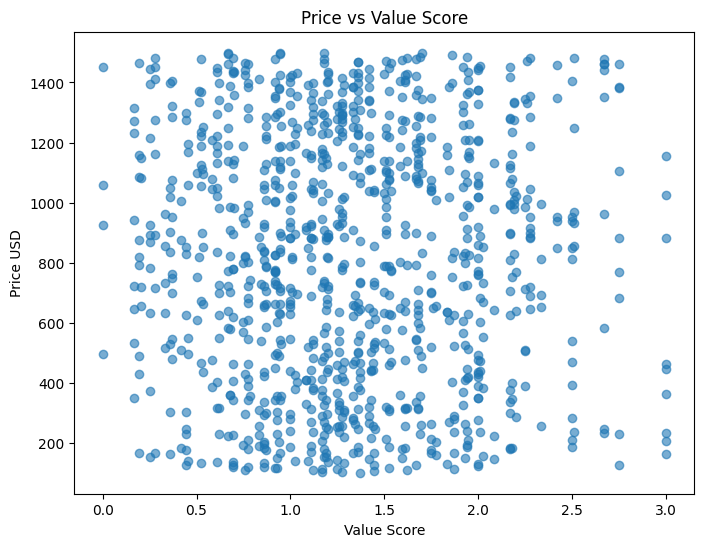

In [15]:

plt.figure(figsize=(8,6))
plt.scatter(df['Value_Score'], df['price_usd'], alpha=0.6)
plt.xlabel('Value Score')
plt.ylabel('Price USD')
plt.title('Price vs Value Score')
plt.show()



# Additional Visualizations


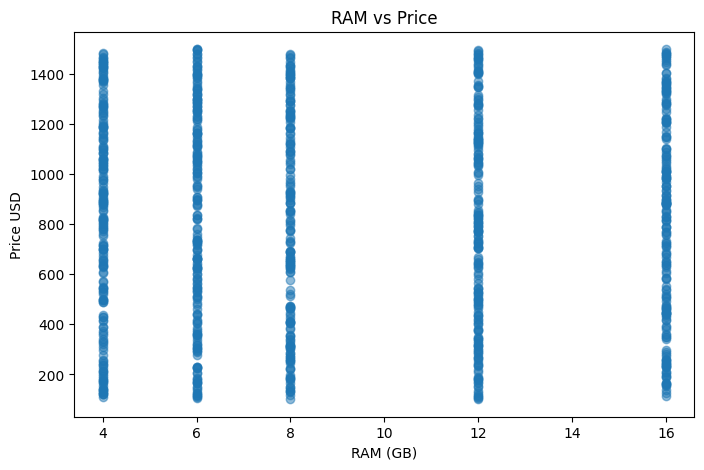

In [16]:

plt.figure(figsize=(8,5))
plt.scatter(df['ram_gb'], df['price_usd'], alpha=0.5)
plt.xlabel('RAM (GB)')
plt.ylabel('Price USD')
plt.title('RAM vs Price')
plt.show()


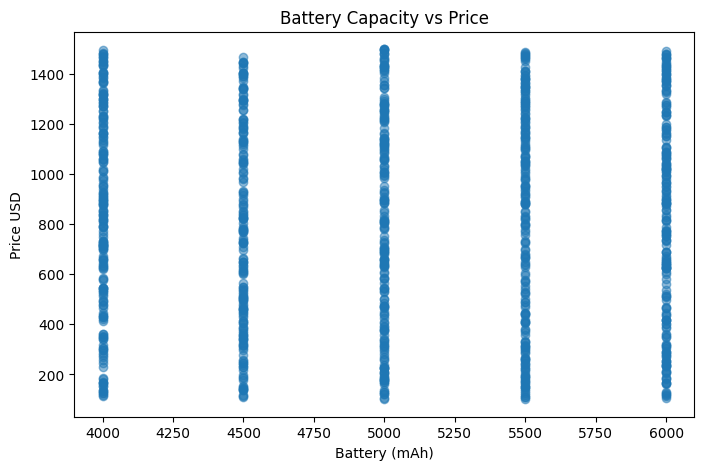

In [17]:

plt.figure(figsize=(8,5))
plt.scatter(df['battery_mah'], df['price_usd'], alpha=0.5)
plt.xlabel('Battery (mAh)')
plt.ylabel('Price USD')
plt.title('Battery Capacity vs Price')
plt.show()


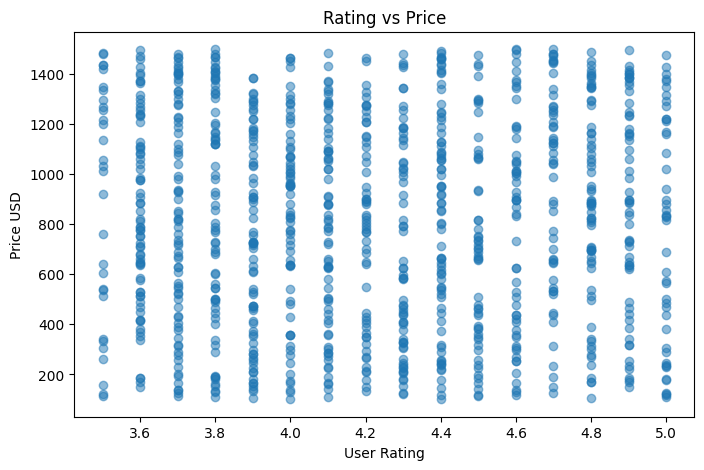

In [18]:

plt.figure(figsize=(8,5))
plt.scatter(df['rating'], df['price_usd'], alpha=0.5)
plt.xlabel('User Rating')
plt.ylabel('Price USD')
plt.title('Rating vs Price')
plt.show()


# Summary
- OS groups show clear price differences  
- RAM, camera, and battery correlate strongly with price  
- Value Score helps identify best value phones  
- Added visualizations help build intuition about specs vs price  
